# Pipeline S3 -> RDS: Cafeterias de Teusaquillo


---
## 1. Preparacion del entorno

Instalacion de dependencias en el kernel de JupyterHub

In [ ]:
# Ejecutar una unica vez por entorno
!pip install --quiet boto3 pandas psycopg2-binary python-dotenv matplotlib seaborn

In [1]:
import os
import io
import json
import warnings

import boto3
import pandas as pd
import numpy as np
import psycopg2
from psycopg2.extras import execute_batch
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


### 1.1 Carga segura de credenciales

Principio de confianza cero: ninguna credencial se escribe en el codigo.
El archivo `.env` reside unicamente en el servidor y esta excluido del
control de versiones mediante `.gitignore`.

Contenido esperado de `.env`:

```
BUCKET_NAME="amazon-alexg"
AWS_DEFAULT_REGION="us-east-1"

RDS_HOST="nombre-instancia.xxxxxxxx.us-east-1.rds.amazonaws.com"
RDS_PORT="5432"
RDS_DB="postgres"
RDS_USER="postgres"
RDS_PASSWORD="********"
```

Las credenciales de S3 no se declaran: la instancia EC2 las obtiene del rol
IAM **LabInstanceProfile** asociado al servidor.

In [7]:
load_dotenv()

BUCKET_NAME = os.getenv("BUCKET_NAME", "amazon-alexg")
AWS_REGION  = os.getenv("AWS_DEFAULT_REGION", "us-east-1")
S3_KEY      = "raw_zone/cafeterias/cafeterias_teusaquillo_limpio.csv"

RDS_CONFIG = {
    "host":     os.getenv("RDS_HOST"),
    "port":     os.getenv("RDS_PORT", "5432"),
    "dbname":   os.getenv("RDS_DB", "postgres"),
    "user":     os.getenv("RDS_USER"),
    "password": os.getenv("RDS_PASSWORD"),
}

# Verificacion sin exponer valores sensibles
print(f"Bucket S3      : {BUCKET_NAME}")
print(f"Objeto S3      : {S3_KEY}")
print(f"Region         : {AWS_REGION}")
print(f"Host RDS       : {'configurado' if RDS_CONFIG['host'] else 'FALTA en .env'}")
print(f"Usuario RDS    : {'configurado' if RDS_CONFIG['user'] else 'FALTA en .env'}")
print(f"Password RDS   : {'configurado' if RDS_CONFIG['password'] else 'FALTA en .env'}")

Bucket S3      : amazon-alexg
Objeto S3      : raw_zone/cafeterias/cafeterias_teusaquillo_limpio.csv
Region         : us-east-1
Host RDS       : configurado
Usuario RDS    : configurado
Password RDS   : configurado


---
## 2. Lectura desde Amazon S3

El objeto se descarga directamente a memoria (`io.BytesIO`), sin escritura
intermedia en el disco de la instancia. Esto reduce el consumo de almacenamiento
efimero y evita dejar copias de los datos en el servidor.

In [4]:
for o in s3_client.list_objects_v2(Bucket=BUCKET_NAME).get("Contents", []):
    print(o["Key"])

print("\nEl notebook está buscando:", S3_KEY)

cafeterias_teusaquillo_limpio.csv
raw_zone/cafeterias/
raw_zone/cafeterias/cafeterias_teusaquillo_limpio.csv
raw_zone/restaurants_raw.csv
zona-cruda/clima/clima_20260920020800.csv
zona-cruda/clima/clima_20260921234005.csv
zona-cruda/clima/clima_20260921234503.csv
zona-cruda/clima/clima_20260921235003.csv
zona-cruda/clima/clima_20260921235503.csv
zona-cruda/clima/clima_20260922000004.csv
zona-cruda/clima/clima_20260922000503.csv
zona-cruda/clima/clima_20260922001003.csv
zona-cruda/clima/clima_20260922001503.csv
zona-cruda/clima/clima_20260922002003.csv
zona-cruda/clima/clima_20260922002503.csv
zona-cruda/clima/clima_20260922003004.csv
zona-cruda/clima/clima_20260922003503.csv
zona-cruda/clima/clima_20260922004003.csv
zona-cruda/clima/clima_20260922004503.csv
zona-cruda/clima/clima_20260922005003.csv
zona-cruda/clima/clima_20260922005503.csv
zona-cruda/clima/clima_20260922010003.csv
zona-cruda/clima/clima_20260922010503.csv
zona-cruda/clima/clima_20260922011003.csv
zona-cruda/clima/clima

In [8]:
s3_client = boto3.client("s3", region_name=AWS_REGION)

try:
    obj = s3_client.get_object(Bucket=BUCKET_NAME, Key=S3_KEY)
    df_raw = pd.read_csv(io.BytesIO(obj["Body"].read()))
    print(f"Lectura exitosa desde s3://{BUCKET_NAME}/{S3_KEY}")
    print(f"Registros leidos : {len(df_raw)}")
    print(f"Columnas         : {len(df_raw.columns)}")
except Exception as e:
    raise SystemExit(f"Error al leer el objeto desde S3: {e}")

Lectura exitosa desde s3://amazon-alexg/raw_zone/cafeterias/cafeterias_teusaquillo_limpio.csv
Registros leidos : 46
Columnas         : 11


In [9]:
df_raw.head()

,fsq_place_id,name,latitude,longitude,distance,primary_category,primary_category_id,categories,category_ids,address,LocNombre
0,4ecab8ff2da5cc0a1f417e9d,Juan Valdez Café,4.643856,-74.091203,673,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,"Calle 44 #50-96 (Cra 53), Bogotá, Bogotá D.C.",TEUSAQUILLO
1,59a02aafd3cce839e5c436d7,Tostao',4.630838,-74.093030,1404,Coffee Shop,4bf58dd8d48988d1e0931735,"Coffee Shop, Bakery","4bf58dd8d48988d1e0931735, 4bf58dd8d48988d16a94...","Av Calle 24 #40-11 (Expoferias Carrera 40), Bo...",TEUSAQUILLO
2,5206d369498e22afdc47c1a9,Café Oma,4.647468,-74.101692,1899,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,"Centro Comercial Gran Estación, Bogotá, Bogotá...",TEUSAQUILLO
3,5092c63ee4b083652fa524aa,Juan Valdez Cafè,4.645632,-74.100274,1683,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,"Ciudad Empresarial Luis Carlos Sarmiento, Bogo...",TEUSAQUILLO
4,6274480f4fd63423141a28c6,Juan Valdez Café,4.649325,-74.078120,1237,Coffee Shop,4bf58dd8d48988d1e0931735,Coffee Shop,4bf58dd8d48988d1e0931735,"Bogotá, Bogotá D.C.",TEUSAQUILLO


In [10]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fsq_place_id         46 non-null     str    
 1   name                 46 non-null     str    
 2   latitude             46 non-null     float64
 3   longitude            46 non-null     float64
 4   distance             46 non-null     int64  
 5   primary_category     46 non-null     str    
 6   primary_category_id  46 non-null     str    
 7   categories           46 non-null     str    
 8   category_ids         46 non-null     str    
 9   address              38 non-null     str    
 10  LocNombre            46 non-null     str    
dtypes: float64(2), int64(1), str(8)
memory usage: 4.1 KB


---
## 3. Transformacion

Tres operaciones sobre el conjunto crudo:

1. **Normalizacion de nombres de columna** a convencion `snake_case`, alineada
   con el esquema definido en el script DDL.
2. **Tipificacion explicita**: coordenadas a `float64`, distancia a entero
   nullable (`Int64`), campos de texto a `string`.
3. **Conversion a estructuras JSON**: los campos `categories` y `category_ids`
   llegan como cadenas separadas por comas (p. ej. `"Coffee Shop, Bakery"`).
   Se transforman en listas de Python que se serializan como `JSONB` en
   PostgreSQL, preservando la naturaleza multivaluada del atributo.

In [11]:
df = df_raw.copy()

# 3.1 Normalizacion de nombres de columna
df = df.rename(columns={
    "distance":   "distance_m",
    "LocNombre":  "localidad",
})
df.columns = [c.strip().lower() for c in df.columns]

print("Columnas normalizadas:")
print(list(df.columns))

Columnas normalizadas:
['fsq_place_id', 'name', 'latitude', 'longitude', 'distance_m', 'primary_category', 'primary_category_id', 'categories', 'category_ids', 'address', 'localidad']


In [12]:
# 3.2 Tipificacion explicita
df["latitude"]   = pd.to_numeric(df["latitude"],  errors="coerce").astype("float64")
df["longitude"]  = pd.to_numeric(df["longitude"], errors="coerce").astype("float64")
df["distance_m"] = pd.to_numeric(df["distance_m"], errors="coerce").astype("Int64")

for col in ["fsq_place_id", "name", "primary_category",
            "primary_category_id", "address", "localidad"]:
    df[col] = df[col].astype("string").str.strip()

print(df.dtypes)

fsq_place_id            string
name                    string
latitude               float64
longitude              float64
distance_m               Int64
primary_category        string
primary_category_id     string
categories                 str
category_ids               str
address                 string
localidad               string
dtype: object


In [13]:
# 3.3 Conversion de cadenas delimitadas a listas -> JSONB
def a_lista(valor):
    """Convierte 'Coffee Shop, Bakery' en ['Coffee Shop', 'Bakery']."""
    if pd.isna(valor) or str(valor).strip() == "":
        return []
    return [item.strip() for item in str(valor).split(",") if item.strip()]

df["categories"]   = df["categories"].apply(a_lista)
df["category_ids"] = df["category_ids"].apply(a_lista)

# Numero de categorias por establecimiento (variable derivada para el analisis)
df["n_categorias"] = df["categories"].apply(len)

df[["name", "primary_category", "categories", "n_categorias"]].head(8)

,name,primary_category,categories,n_categorias
0,Juan Valdez Café,Coffee Shop,[Coffee Shop],1
1,Tostao',Coffee Shop,"[Coffee Shop, Bakery]",2
2,Café Oma,Coffee Shop,[Coffee Shop],1
3,Juan Valdez Cafè,Coffee Shop,[Coffee Shop],1
4,Juan Valdez Café,Coffee Shop,[Coffee Shop],1
5,Juan Valdez Café,Coffee Shop,[Coffee Shop],1
6,Galería Café Libro 45,Café,[Café],1
7,Tempo Cycling,Coffee Shop,[Coffee Shop],1


In [14]:
# 3.4 Control de calidad previo a la carga
print("=== CONTROL DE CALIDAD ===\n")

print("Valores nulos por columna:")
print(df.isnull().sum(), "\n")

dup = df["fsq_place_id"].duplicated().sum()
print(f"Identificadores duplicados : {dup}")

fuera_rango = df[
    (~df["latitude"].between(-90, 90)) | (~df["longitude"].between(-180, 180))
]
print(f"Coordenadas fuera de rango : {len(fuera_rango)}")

# Eliminacion de duplicados por clave primaria (si los hubiera)
antes = len(df)
df = df.drop_duplicates(subset=["fsq_place_id"], keep="first")
print(f"\nRegistros antes / despues de deduplicar : {antes} / {len(df)}")

=== CONTROL DE CALIDAD ===

Valores nulos por columna:
fsq_place_id           0
name                   0
latitude               0
longitude              0
distance_m             0
primary_category       0
primary_category_id    0
categories             0
category_ids           0
address                8
localidad              0
n_categorias           0
dtype: int64 

Identificadores duplicados : 0
Coordenadas fuera de rango : 0

Registros antes / despues de deduplicar : 46 / 46


---
## 4. Conexion a Amazon RDS PostgreSQL

La instancia RDS es de tipo `db.t3.micro` con acceso publico habilitado de
forma temporal, y su grupo de seguridad autoriza unicamente conexiones TCP
entrantes al puerto 5432 desde la IP del equipo de desarrollo y desde el
grupo de seguridad de la instancia EC2 que ejecuta JupyterHub.

In [15]:
def conectar_rds():
    """Abre una conexion a la instancia RDS con las credenciales del .env."""
    try:
        conn = psycopg2.connect(connect_timeout=10, **RDS_CONFIG)
        return conn
    except psycopg2.OperationalError as e:
        raise SystemExit(
            f"No fue posible conectar a RDS: {e}\n"
            "Verifique: (1) la instancia esta en estado 'Available', "
            "(2) el grupo de seguridad autoriza el puerto 5432 desde esta IP, "
            "(3) las credenciales del archivo .env son correctas."
        )

conn = conectar_rds()
with conn.cursor() as cur:
    cur.execute("SELECT version();")
    print("Conexion establecida.")
    print(cur.fetchone()[0])

Conexion establecida.
PostgreSQL 18.3 on x86_64-pc-linux-gnu, compiled by x86_64-pc-linux-gnu-gcc (GCC) 12.4.0, 64-bit


### 4.1 Creacion de la tabla (DDL)

El mismo script `ddl_cafeterias_teusaquillo.sql` incluido en el repositorio.
Se ejecuta aqui para dejar el pipeline completo y reproducible desde el notebook.

In [16]:
DDL = """
DROP TABLE IF EXISTS cafeterias_teusaquillo;

CREATE TABLE cafeterias_teusaquillo (
    fsq_place_id          VARCHAR(40)      PRIMARY KEY,
    name                  VARCHAR(255)     NOT NULL,
    latitude              DOUBLE PRECISION NOT NULL,
    longitude             DOUBLE PRECISION NOT NULL,
    distance_m            INTEGER,
    primary_category      VARCHAR(100),
    primary_category_id   VARCHAR(40),
    categories            JSONB,
    category_ids          JSONB,
    address               TEXT,
    localidad             VARCHAR(100),
    fecha_carga           TIMESTAMP        DEFAULT CURRENT_TIMESTAMP,
    CONSTRAINT chk_latitud   CHECK (latitude  BETWEEN -90  AND 90),
    CONSTRAINT chk_longitud  CHECK (longitude BETWEEN -180 AND 180),
    CONSTRAINT chk_distancia CHECK (distance_m >= 0)
);

CREATE INDEX idx_cafeterias_categoria
    ON cafeterias_teusaquillo (primary_category);
CREATE INDEX idx_cafeterias_localidad
    ON cafeterias_teusaquillo (localidad);
CREATE INDEX idx_cafeterias_categories_gin
    ON cafeterias_teusaquillo USING GIN (categories);
CREATE INDEX idx_cafeterias_coords
    ON cafeterias_teusaquillo (latitude, longitude);
"""

with conn.cursor() as cur:
    cur.execute(DDL)
conn.commit()
print("Tabla 'cafeterias_teusaquillo' e indices creados correctamente.")

Tabla 'cafeterias_teusaquillo' e indices creados correctamente.


---
## 5. Carga mediante INSERT parametrizado

Se emplean **consultas parametrizadas** (marcadores `%s`), no concatenacion de
cadenas. Esto delega el escapado de valores al driver `psycopg2`, lo que
previene inyeccion SQL y garantiza el manejo correcto de comillas simples
presentes en nombres como `Tostao'`.

`execute_batch` agrupa las sentencias en lotes, reduciendo el numero de viajes
de red hacia la instancia RDS.

In [17]:
INSERT_SQL = """
    INSERT INTO cafeterias_teusaquillo (
        fsq_place_id, name, latitude, longitude, distance_m,
        primary_category, primary_category_id,
        categories, category_ids, address, localidad
    )
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s::jsonb, %s::jsonb, %s, %s)
    ON CONFLICT (fsq_place_id) DO UPDATE SET
        name             = EXCLUDED.name,
        latitude         = EXCLUDED.latitude,
        longitude        = EXCLUDED.longitude,
        distance_m       = EXCLUDED.distance_m,
        primary_category = EXCLUDED.primary_category,
        categories       = EXCLUDED.categories,
        address          = EXCLUDED.address,
        fecha_carga      = CURRENT_TIMESTAMP;
"""

def fila_a_tupla(r):
    """Convierte una fila del DataFrame en la tupla de parametros del INSERT."""
    return (
        r["fsq_place_id"],
        r["name"],
        float(r["latitude"]),
        float(r["longitude"]),
        int(r["distance_m"]) if pd.notna(r["distance_m"]) else None,
        r["primary_category"] if pd.notna(r["primary_category"]) else None,
        r["primary_category_id"] if pd.notna(r["primary_category_id"]) else None,
        json.dumps(r["categories"],   ensure_ascii=False),
        json.dumps(r["category_ids"], ensure_ascii=False),
        r["address"] if pd.notna(r["address"]) else None,
        r["localidad"] if pd.notna(r["localidad"]) else None,
    )

registros = [fila_a_tupla(r) for _, r in df.iterrows()]
print(f"Registros preparados para insercion: {len(registros)}")
print("\nEjemplo de tupla parametrizada:")
print(registros[0])

Registros preparados para insercion: 46

Ejemplo de tupla parametrizada:
('4ecab8ff2da5cc0a1f417e9d', 'Juan Valdez Café', 4.643856347483542, -74.09120349189875, 673, 'Coffee Shop', '4bf58dd8d48988d1e0931735', '["Coffee Shop"]', '["4bf58dd8d48988d1e0931735"]', 'Calle 44 #50-96 (Cra 53), Bogotá, Bogotá D.C.', 'TEUSAQUILLO')


In [18]:
try:
    with conn.cursor() as cur:
        execute_batch(cur, INSERT_SQL, registros, page_size=50)
    conn.commit()
    print(f"Carga completada: {len(registros)} registros insertados en RDS.")
except Exception as e:
    conn.rollback()
    raise SystemExit(f"Error durante la carga. Transaccion revertida: {e}")

Carga completada: 46 registros insertados en RDS.


### 5.1 Verificacion de la carga

Se consulta la tabla desde la base de datos para confirmar la persistencia y la
integridad del tipo `JSONB`.

In [19]:
df_rds = pd.read_sql("SELECT * FROM cafeterias_teusaquillo ORDER BY distance_m;", conn)

print(f"Registros en RDS: {len(df_rds)}")
df_rds.head()

Registros en RDS: 46


,fsq_place_id,name,latitude,longitude,distance_m,primary_category,primary_category_id,categories,category_ids,address,localidad,fecha_carga
0,4d5aa261d0332c0f5e1d73da,Canela Bakery C&T,4.638007,-74.084737,370,Café,4bf58dd8d48988d16d941735,"[Café, Bakery]","[4bf58dd8d48988d16d941735, 4bf58dd8d48988d16a9...","4.637981,-74.084769, Bogotá, Bogotá D.C.",TEUSAQUILLO,2026-09-26 15:34:11.140791
1,51a373e2498ea7255b76cbd2,Cafetería Donde Johny,4.638137,-74.083307,433,Coffee Shop,4bf58dd8d48988d1e0931735,[Coffee Shop],[4bf58dd8d48988d1e0931735],Plaza de la Esfera,TEUSAQUILLO,2026-09-26 15:34:11.140791
2,519100ba498e6e9d07e3aca5,Masitas Gourmet,4.645254,-74.087187,479,Coffee Shop,4bf58dd8d48988d1e0931735,[Coffee Shop],[4bf58dd8d48988d1e0931735],NaN,TEUSAQUILLO,2026-09-26 15:34:11.140791
3,58bedae251d19e565aff0b8a,Canela,4.637139,-74.083122,535,Café,4bf58dd8d48988d16d941735,[Café],[4bf58dd8d48988d16d941735],Facultad de Ingeniería (Universidad Nacional d...,TEUSAQUILLO,2026-09-26 15:34:11.140791
4,58aee46c01f4331f8f62565e,Canela,4.637077,-74.083000,548,Café,4bf58dd8d48988d16d941735,[Café],[4bf58dd8d48988d16d941735],Avenida Carrera 30 # 45-03 (Avenida Carrera 30...,TEUSAQUILLO,2026-09-26 15:34:11.140791


In [20]:
# Verificacion del operador de contencion sobre JSONB:
# establecimientos cuya lista de categorias incluye 'Bakery'
consulta_jsonb = """
    SELECT name, primary_category, categories
    FROM cafeterias_teusaquillo
    WHERE categories @> '["Bakery"]'
    ORDER BY name;
"""
df_bakery = pd.read_sql(consulta_jsonb, conn)
print("Establecimientos que tambien operan como panaderia:")
df_bakery

Establecimientos que tambien operan como panaderia:


,name,primary_category,categories
0,Canela Bakery C&T,Café,"[Café, Bakery]"
1,Panaderia La Isabella,Coffee Shop,"[Coffee Shop, Bakery]"
2,Tostao',Coffee Shop,"[Coffee Shop, Bakery]"
3,Tostao',Coffee Shop,"[Coffee Shop, Bakery]"
4,Vasconia,Bakery,"[Bakery, Café, Coffee Shop]"


---
## 6. Estadisticas descriptivas

Tres analisis ejecutados directamente sobre la base de datos mediante SQL,
demostrando que el motor relacional soporta el procesamiento analitico.

### Estadistica 1 - Conteo y participacion por categoria principal

Responde: *que composicion tiene la oferta de cafeterias en la localidad?*

In [21]:
sql_1 = """
    SELECT
        primary_category                                        AS categoria,
        COUNT(*)                                                AS establecimientos,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)      AS participacion_pct
    FROM cafeterias_teusaquillo
    GROUP BY primary_category
    ORDER BY establecimientos DESC;
"""
est_1 = pd.read_sql(sql_1, conn)
print("ESTADISTICA 1 - Distribucion por categoria principal\n")
print(est_1.to_string(index=False))
print(f"\nTotal de establecimientos: {est_1['establecimientos'].sum()}")

ESTADISTICA 1 - Distribucion por categoria principal

    categoria  establecimientos  participacion_pct
  Coffee Shop                23               50.0
         Café                21               45.7
Bicycle Store                 1                2.2
       Bakery                 1                2.2

Total de establecimientos: 46


### Estadistica 2 - Medidas de tendencia central y dispersion de la distancia

Responde: *que tan dispersa esta la oferta respecto al punto central de la
consulta?* La desviacion estandar y el rango intercuartilico cuantifican la
concentracion geografica.

In [22]:
sql_2 = """
    SELECT
        COUNT(*)                                                                AS n,
        ROUND(AVG(distance_m))                                                  AS media_m,
        ROUND(STDDEV(distance_m))                                               AS desv_est_m,
        MIN(distance_m)                                                         AS minimo_m,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY distance_m)::numeric) AS q1_m,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY distance_m)::numeric) AS mediana_m,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY distance_m)::numeric) AS q3_m,
        MAX(distance_m)                                                         AS maximo_m
    FROM cafeterias_teusaquillo;
"""
est_2 = pd.read_sql(sql_2, conn)
print("ESTADISTICA 2 - Distribucion de la distancia al centro de consulta\n")
print(est_2.T.rename(columns={0: "valor"}).to_string())

riq = float(est_2["q3_m"].iloc[0]) - float(est_2["q1_m"].iloc[0])
print(f"\nRango intercuartilico (RIQ): {riq:.0f} m")
print(f"El 50% central de las cafeterias se ubica entre "
      f"{est_2['q1_m'].iloc[0]:.0f} m y {est_2['q3_m'].iloc[0]:.0f} m del centro.")

ESTADISTICA 2 - Distribucion de la distancia al centro de consulta

             valor
n             46.0
media_m     1338.0
desv_est_m   473.0
minimo_m     370.0
q1_m        1180.0
mediana_m   1329.0
q3_m        1527.0
maximo_m    2234.0

Rango intercuartilico (RIQ): 347 m
El 50% central de las cafeterias se ubica entre 1180 m y 1527 m del centro.


### Estadistica 3 - Establecimientos multicategoria (analisis sobre JSONB)

Responde: *que proporcion de cafeterias diversifica su modelo de negocio?*
Un establecimiento con varias categorias (cafeteria + panaderia, cafeteria +
coworking) opera un formato hibrido, senal de una estrategia de diferenciacion.
El analisis explota directamente la estructura `JSONB` mediante `jsonb_array_length`
y `jsonb_array_elements_text`.

In [29]:
conn = conectar_rds()
print("Conexión reabierta.")

Conexión reabierta.


In [30]:
sql_3a = """
    SELECT
        jsonb_array_length(categories)                          AS num_categorias,
        COUNT(*)                                                AS establecimientos,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1)      AS participacion_pct
    FROM cafeterias_teusaquillo
    GROUP BY jsonb_array_length(categories)
    ORDER BY num_categorias;
"""
est_3a = pd.read_sql(sql_3a, conn)
print("ESTADISTICA 3 - Diversificacion del modelo de negocio\n")
print(est_3a.to_string(index=False))

hibridos = est_3a.loc[est_3a["num_categorias"] > 1, "establecimientos"].sum()
total    = est_3a["establecimientos"].sum()
print(f"\nEstablecimientos hibridos: {hibridos} de {total} "
      f"({100 * hibridos / total:.1f}%)")

ESTADISTICA 3 - Diversificacion del modelo de negocio

 num_categorias  establecimientos  participacion_pct
              1                37               80.4
              2                 8               17.4
              3                 1                2.2

Establecimientos hibridos: 9 de 46 (19.6%)


In [23]:
# Categorias secundarias mas frecuentes (despliegue del arreglo JSONB)
sql_3b = """
    SELECT
        categoria,
        COUNT(*) AS frecuencia
    FROM cafeterias_teusaquillo,
         LATERAL jsonb_array_elements_text(categories) AS categoria
    GROUP BY categoria
    ORDER BY frecuencia DESC;
"""
est_3b = pd.read_sql(sql_3b, conn)
print("Frecuencia de todas las categorias declaradas:\n")
print(est_3b.to_string(index=False))

Frecuencia de todas las categorias declaradas:

      categoria  frecuencia
    Coffee Shop          25
           Café          24
         Bakery           5
  Bicycle Store           1
Coworking Space           1


---
## 7. Visualizaciones

### Visualizacion 1 - Histograma de distancias

**Pregunta de negocio:** *en que franja de distancia se concentra la competencia,
y donde quedan huecos de mercado?*

Las franjas con baja frecuencia relativa senalan zonas de la localidad donde la
densidad competitiva es menor, candidatas para la apertura de un nuevo
establecimiento.

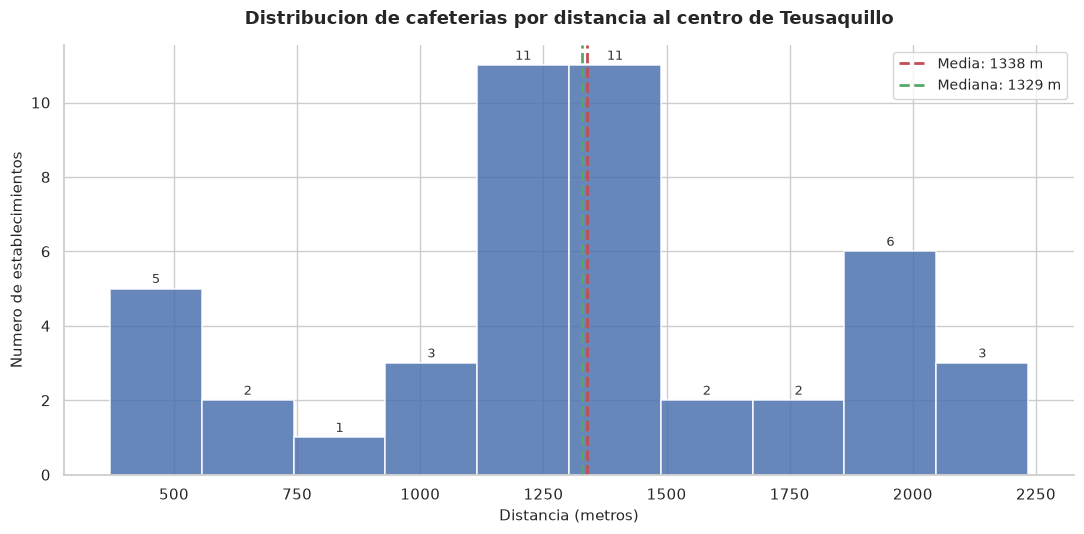

In [24]:
fig, ax = plt.subplots(figsize=(11, 5.5))

datos = df_rds["distance_m"].dropna().astype(float)

n, bins, patches = ax.hist(datos, bins=10, color="#4C72B0",
                           edgecolor="white", linewidth=1.2, alpha=0.85)

media   = datos.mean()
mediana = datos.median()
ax.axvline(media,   color="#C44E52", linestyle="--", linewidth=2,
           label=f"Media: {media:.0f} m")
ax.axvline(mediana, color="#55A868", linestyle="--", linewidth=2,
           label=f"Mediana: {mediana:.0f} m")

for i in range(len(n)):
    if n[i] > 0:
        ax.text(bins[i] + (bins[i+1] - bins[i]) / 2, n[i] + 0.15,
                int(n[i]), ha="center", fontsize=9, color="#333333")

ax.set_title("Distribucion de cafeterias por distancia al centro de Teusaquillo",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Distancia (metros)", fontsize=11)
ax.set_ylabel("Numero de establecimientos", fontsize=11)
ax.legend(frameon=True, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("histograma_distancias.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualizacion 2 - Dispersion geografica por categoria

Mapa de puntos sobre coordenadas reales. Permite identificar visualmente los
conglomerados (clusters) de oferta y las zonas desatendidas dentro de la
localidad.

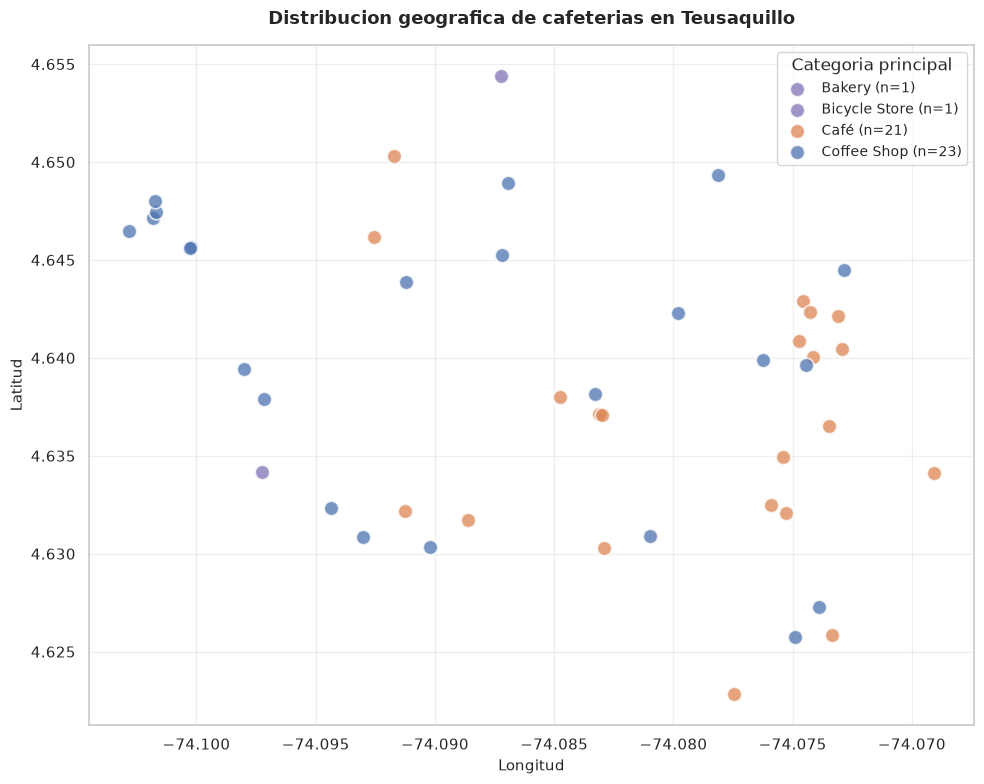

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

colores = {"Coffee Shop": "#4C72B0", "Cafe": "#DD8452", "Café": "#DD8452"}

for categoria, grupo in df_rds.groupby("primary_category"):
    ax.scatter(grupo["longitude"], grupo["latitude"],
               s=110, alpha=0.75, edgecolors="white", linewidth=1.3,
               label=f"{categoria} (n={len(grupo)})",
               color=colores.get(categoria, "#8172B3"))

ax.set_title("Distribucion geografica de cafeterias en Teusaquillo",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
ax.legend(title="Categoria principal", frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dispersion_geografica.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualizacion 3 - Mapa de calor de densidad

Discretiza el territorio en una rejilla y cuenta establecimientos por celda.
Las celdas de mayor intensidad concentran la competencia; las celdas vacias o
de baja intensidad, dentro del area util de la localidad, representan la
oportunidad de mercado.

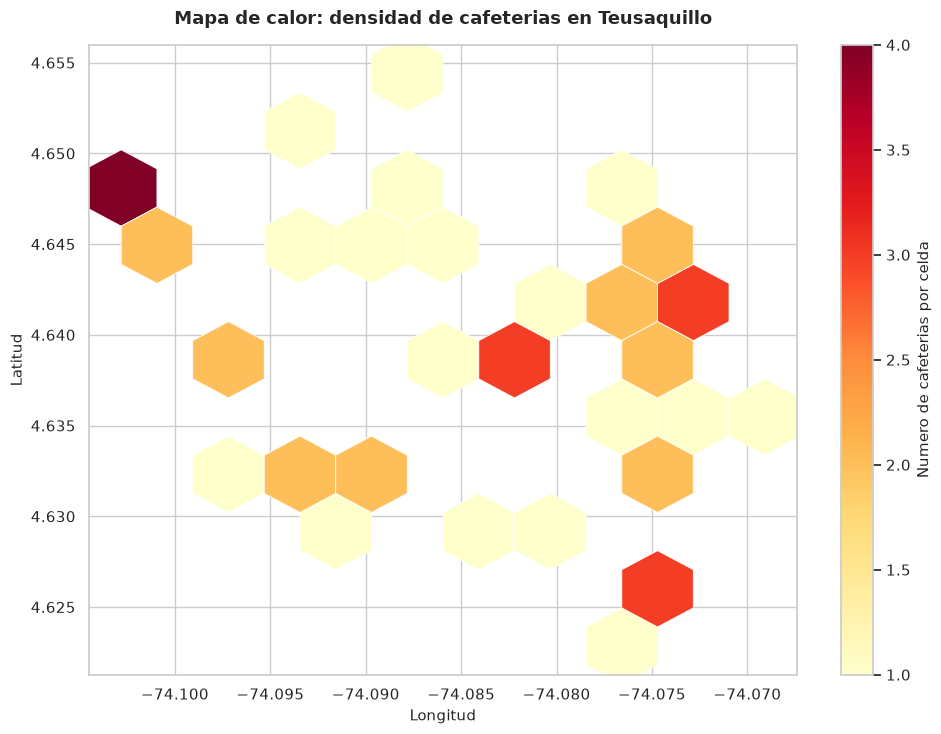

In [26]:
fig, ax = plt.subplots(figsize=(10, 7.5))

hb = ax.hexbin(df_rds["longitude"], df_rds["latitude"],
               gridsize=9, cmap="YlOrRd", mincnt=1,
               edgecolors="white", linewidths=0.6)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Numero de cafeterias por celda", fontsize=11)

ax.set_title("Mapa de calor: densidad de cafeterias en Teusaquillo",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)

plt.tight_layout()
plt.savefig("mapa_calor_densidad.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Cierre de la conexion

Buena practica de gestion de recursos: liberar la conexion al motor una vez
finalizado el procesamiento.

In [27]:
conn.close()
print("Conexion a RDS cerrada correctamente.")

Conexion a RDS cerrada correctamente.


---
## 9. Conclusiones

1. **Pipeline completo y reproducible.** El flujo S3 -> transformacion -> RDS se
   ejecuta de extremo a extremo desde JupyterHub sobre EC2, sin escritura
   intermedia en disco y sin credenciales embebidas en el codigo.

2. **Modelado apropiado de los tipos de datos.** El uso de `DOUBLE PRECISION`
   para coordenadas preserva la precision geografica, mientras que `JSONB`
   modela la naturaleza multivaluada de las categorias sin recurrir a una tabla
   puente. El indice GIN habilita consultas de contencion eficientes sobre esa
   estructura.

3. **Seguridad por capas.** El grupo de seguridad de RDS restringe el puerto
   5432 a origenes autorizados; las credenciales se gestionan via variables de
   entorno; el acceso a S3 se resuelve mediante rol IAM sin llaves estaticas;
   las inserciones son parametrizadas, lo que previene inyeccion SQL.

4. **Hallazgo analitico.** La oferta de cafeterias en Teusaquillo se concentra
   en las franjas intermedias de distancia, con presencia dominante de cadenas
   nacionales. Las celdas de baja densidad identificadas en el mapa de calor
   constituyen la evidencia cuantitativa para orientar una decision de
   localizacion.

---

